# LAB016–LAB018 — Exploratory visualization of CO2, temperature and pump states

**Purpose:** descriptive inspection of the parallel fermentation run **LAB016 (F1)**, **LAB017 (F2)**, **LAB018 (F3)**: raw-file overview, common elapsed-time axis, filtered CO2 converted to g L⁻¹ h⁻¹, and pump activation pulses.

**Data** (`fermentation_model/data/mem2026/LAB016-018/`):

| LAB | Fermenter | Raw CO2 | Filtered CO2 (plotted) | Temperature + pump states |
| --- | --- | --- | --- | --- |
| LAB016 | F1 | `CO2_F1_LAB016.csv` | `CO2_FILT_F1_LAB016.csv` | `Temp_F1_LAB016.csv` |
| LAB017 | F2 | `CO2_F2_LAB017.csv` | `CO2_FILT_F2_LAB017.csv` | `Temp_F2_LAB017.csv` |
| LAB018 | F3 | `CO2_F3_LAB018.csv` | `CO2_FILT_F3_LAB018.csv` | `Temp_F3._LAB018.csv` |

**Units — verified on the CSVs; official conversion applied in memory for plotting only:**

- The `CO2_FILT_*` files store the offline-filtered signal in the column **`flow_filt_sccm`**, i.e. **SCCM** (same scale as the raw `flow_sccm`; per-fermenter raw/filtered mean ratio ≈ 0.99). **The CSVs do not contain a converted signal.**
- This notebook applies the **official repository conversion SCCM → g L⁻¹ h⁻¹**, replicated exactly from `lab090226_lab290226_co2_offline_filter_analysis.ipynb` (which replicates `flow_sccm_to_co2_g_l_h_plot` from `NEW_GUI_filtrado_vFINAL.py`): **1 SCCM ≈ 0.04044 g L⁻¹ h⁻¹** (constants: molar volume 24.16 L/mol, molar mass 44.0095 g/mol, reactor working volume 2.0 L, correction factor 0.74). The conversion is **in memory, visualization only** — no CSV is modified and no signal is re-filtered.
- Temperature: `T` → **°C**, controlled at setpoint **SP = 20.0 °C** (band 0.5 °C); annotated explicitly in the main figure.

**Pump/activation channels (from the `Temp_*` CSVs):** `cold`, `hot` and `nutricion_activa` are 0/1 activation states and are drawn as digital pulse lanes in the main figure. `freq_nut` (alternates 1000/4000) is a pump frequency **setting**, not an ON/OFF state, and is excluded.

This notebook is **exploratory/descriptive only**: signals are plotted as recorded — **no additional filtering, no model fitting, no parameter estimation**, and no processed files are written.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

%matplotlib inline

# Project root (notebook lives in fermentation_model/laboratory_2026/notebooks/)
ROOT = Path.cwd()
while ROOT.name != 'pyomo-doe' and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != 'pyomo-doe':
    raise RuntimeError('Project root pyomo-doe not found from ' + str(Path.cwd()))

DATA_DIR = ROOT / 'fermentation_model' / 'data' / 'mem2026' / 'LAB016-018'

# NOTE: the F3 temperature file has a literal extra dot in its name on disk.
LABS = {
    'LAB016': {'fermenter': 'F1',
               'co2_raw': 'CO2_F1_LAB016.csv',
               'co2_filt': 'CO2_FILT_F1_LAB016.csv',
               'temp': 'Temp_F1_LAB016.csv'},
    'LAB017': {'fermenter': 'F2',
               'co2_raw': 'CO2_F2_LAB017.csv',
               'co2_filt': 'CO2_FILT_F2_LAB017.csv',
               'temp': 'Temp_F2_LAB017.csv'},
    'LAB018': {'fermenter': 'F3',
               'co2_raw': 'CO2_F3_LAB018.csv',
               'co2_filt': 'CO2_FILT_F3_LAB018.csv',
               'temp': 'Temp_F3._LAB018.csv'},
}

CO2_RAW_COL = 'flow_sccm'        # SCCM
CO2_FILT_COL = 'flow_filt_sccm'  # SCCM
TEMP_COL = 'T'                   # degC

data = {}
for lab, spec in LABS.items():
    data[lab] = {
        'fermenter': spec['fermenter'],
        'co2_raw': pd.read_csv(DATA_DIR / spec['co2_raw'], parse_dates=['timestamp']),
        'co2_filt': pd.read_csv(DATA_DIR / spec['co2_filt'], parse_dates=['timestamp']),
        'temp': pd.read_csv(DATA_DIR / spec['temp'], parse_dates=['timestamp']),
    }
    d = data[lab]
    print(lab + ' (' + spec['fermenter'] + '): co2_raw ' + str(d['co2_raw'].shape) +
          ', co2_filt ' + str(d['co2_filt'].shape) + ', temp ' + str(d['temp'].shape))

print('DATA_DIR =', DATA_DIR)
data['LAB016']['co2_filt'].head()

LAB016 (F1): co2_raw (47785, 4), co2_filt (47785, 5), temp (95143, 9)


LAB017 (F2): co2_raw (47788, 4), co2_filt (47787, 5), temp (95153, 9)


LAB018 (F3): co2_raw (47788, 4), co2_filt (47788, 5), temp (95154, 9)
DATA_DIR = D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe\fermentation_model\data\mem2026\LAB016-018


,timestamp,fermentador,flow_filt_sccm,status,is_spike
0,2026-08-31 17:17:29,F1,0.4705,OK,0
1,2026-08-31 17:17:39,F1,0.4703,OK,0
2,2026-08-31 17:17:50,F1,0.4701,OK,0
3,2026-08-31 17:18:00,F1,0.4699,OK,0
4,2026-08-31 17:18:10,F1,0.4697,OK,0


In [2]:
def file_summary(name, df, value_col, unit):
    ts = df['timestamp']
    dt = ts.diff().dt.total_seconds().dropna()
    return {
        'file': name,
        'value_column': value_col + ' [' + unit + ']',
        'n_samples': len(df),
        'first_timestamp': ts.iloc[0],
        'last_timestamp': ts.iloc[-1],
        'duration_h': round((ts.iloc[-1] - ts.iloc[0]).total_seconds() / 3600, 3),
        'median_dt_s': float(dt.median()),
        'max_dt_s': float(dt.max()),
        'n_nans': int(df.isna().sum().sum()),
        'dup_timestamps': int(ts.duplicated().sum()),
    }

rows = []
for lab, d in data.items():
    rows.append(file_summary(LABS[lab]['co2_raw'], d['co2_raw'], CO2_RAW_COL, 'SCCM'))
    rows.append(file_summary(LABS[lab]['co2_filt'], d['co2_filt'], CO2_FILT_COL, 'SCCM'))
    rows.append(file_summary(LABS[lab]['temp'], d['temp'], TEMP_COL, 'degC'))

inspection = pd.DataFrame(rows)
display(inspection)

print('Status flags and logging gaps (> 60 s):')
for lab, d in data.items():
    for key in ('co2_raw', 'co2_filt', 'temp'):
        df = d[key]
        ts = df['timestamp']
        dt = ts.diff().dt.total_seconds()
        status = df['status'].value_counts().to_dict() if 'status' in df.columns else {'-': len(df)}
        spikes = int(df['is_spike'].sum()) if 'is_spike' in df.columns else '-'
        gaps = dt[dt > 60]
        if len(gaps):
            gap_txt = str(len(gaps)) + ' gap(s), largest ' + f'{gaps.max():.0f}' + ' s ending ' + str(ts.loc[gaps.idxmax()])
        else:
            gap_txt = 'none'
        print(' ', LABS[lab][key], '->', status, '| is_spike sum:', spikes, '| gaps>60s:', gap_txt)

print()
print('Unit verification of CO2_FILT (raw vs filtered scale, as recorded in the CSVs):')
for lab, d in data.items():
    m_raw = d['co2_raw'][CO2_RAW_COL].mean()
    m_filt = d['co2_filt'][CO2_FILT_COL].mean()
    print(' ', lab, ': mean raw =', f'{m_raw:.3f}', 'SCCM | mean filt =', f'{m_filt:.3f}',
          'SCCM | ratio =', f'{m_filt / m_raw:.3f}')
print('ratio ~ 0.99 for all fermenters -> CO2_FILT is on the same unconverted SCCM scale as the raw signal.')
print('No converted column is present in the CO2_FILT CSVs; conversion is therefore performed only in memory below.')

,file,value_column,n_samples,first_timestamp,last_timestamp,duration_h,median_dt_s,max_dt_s,n_nans,dup_timestamps
0,CO2_F1_LAB016.csv,flow_sccm [SCCM],47785,2026-08-31 17:17:29,2026-09-07 08:09:56,158.874,11.0,3614.0,0,0
1,CO2_FILT_F1_LAB016.csv,flow_filt_sccm [SCCM],47785,2026-08-31 17:17:29,2026-09-07 08:09:56,158.874,11.0,3614.0,0,0
2,Temp_F1_LAB016.csv,T [degC],95143,2026-08-31 17:17:27,2026-09-07 08:09:55,158.874,4.0,3614.0,0,0
3,CO2_F2_LAB017.csv,flow_sccm [SCCM],47788,2026-08-31 17:16:58,2026-09-07 08:09:56,158.883,11.0,3614.0,0,0
4,CO2_FILT_F2_LAB017.csv,flow_filt_sccm [SCCM],47787,2026-08-31 17:17:09,2026-09-07 08:09:56,158.880,11.0,3614.0,0,0
5,Temp_F2_LAB017.csv,T [degC],95153,2026-08-31 17:16:54,2026-09-07 08:09:55,158.884,4.0,3614.0,0,0
6,CO2_F3_LAB018.csv,flow_sccm [SCCM],47788,2026-08-31 17:16:58,2026-09-07 08:09:56,158.883,11.0,3614.0,0,0
7,CO2_FILT_F3_LAB018.csv,flow_filt_sccm [SCCM],47788,2026-08-31 17:16:58,2026-09-07 08:09:56,158.883,11.0,3614.0,0,0
8,Temp_F3._LAB018.csv,T [degC],95154,2026-08-31 17:16:51,2026-09-07 08:09:56,158.885,4.0,3614.0,0,0


Status flags and logging gaps (> 60 s):
  CO2_F1_LAB016.csv -> {'OK': 47714, 'Bajo rango': 66, 'Alto rango': 5} | is_spike sum: - | gaps>60s: 1 gap(s), largest 3614 s ending 2026-09-06 01:00:01
  CO2_FILT_F1_LAB016.csv -> {'OK': 47714, 'Bajo rango': 66, 'Alto rango': 5} | is_spike sum: 2514 | gaps>60s: 1 gap(s), largest 3614 s ending 2026-09-06 01:00:01
  Temp_F1_LAB016.csv -> {'-': 95143} | is_spike sum: - | gaps>60s: 1 gap(s), largest 3614 s ending 2026-09-06 01:00:13
  CO2_F2_LAB017.csv -> {'OK': 46894, 'Bajo rango': 890, 'Alto rango': 4} | is_spike sum: - | gaps>60s: 1 gap(s), largest 3614 s ending 2026-09-06 01:00:01
  CO2_FILT_F2_LAB017.csv -> {'OK': 46893, 'Bajo rango': 890, 'Alto rango': 4} | is_spike sum: 2242 | gaps>60s: 1 gap(s), largest 3614 s ending 2026-09-06 01:00:01
  Temp_F2_LAB017.csv -> {'-': 95153} | is_spike sum: - | gaps>60s: 1 gap(s), largest 3614 s ending 2026-09-06 01:00:00
  CO2_F3_LAB018.csv -> {'OK': 47484, 'Bajo rango': 286, 'Alto rango': 18} | is_spike sum

## Elapsed-time axis `time_h`

LAB016, LAB017 and LAB018 are the **same experiment run in parallel**: the first timestamps of the nine files fall within a **~38-second window** on 2026-08-31 (between 17:16:51 and 17:17:29), i.e. all loggers started essentially together. A single common reference is therefore unambiguous and no arbitrary offset is invented:

- **t0 = earliest timestamp found across the nine CSV files** (computed below directly from the data).
- For every file, `time_h = (timestamp − t0) / 3600`, so the three fermenters are plotted on one directly comparable axis.
- Only the raw-CO2 log of F1 starts ~31 s after t0 (one sampling period), which does not affect the comparison.

In [3]:
firsts = []
for d in data.values():
    for key in ('co2_raw', 'co2_filt', 'temp'):
        firsts.append(d[key]['timestamp'].iloc[0])
T0 = min(firsts)
print('Common time reference t0 =', T0)

for d in data.values():
    for key in ('co2_raw', 'co2_filt', 'temp'):
        df = d[key]
        df['time_h'] = (df['timestamp'] - T0).dt.total_seconds() / 3600.0

Common time reference t0 = 2026-08-31 17:16:51


Official conversion factor: 1 SCCM = 0.04044 g L^-1 h^-1


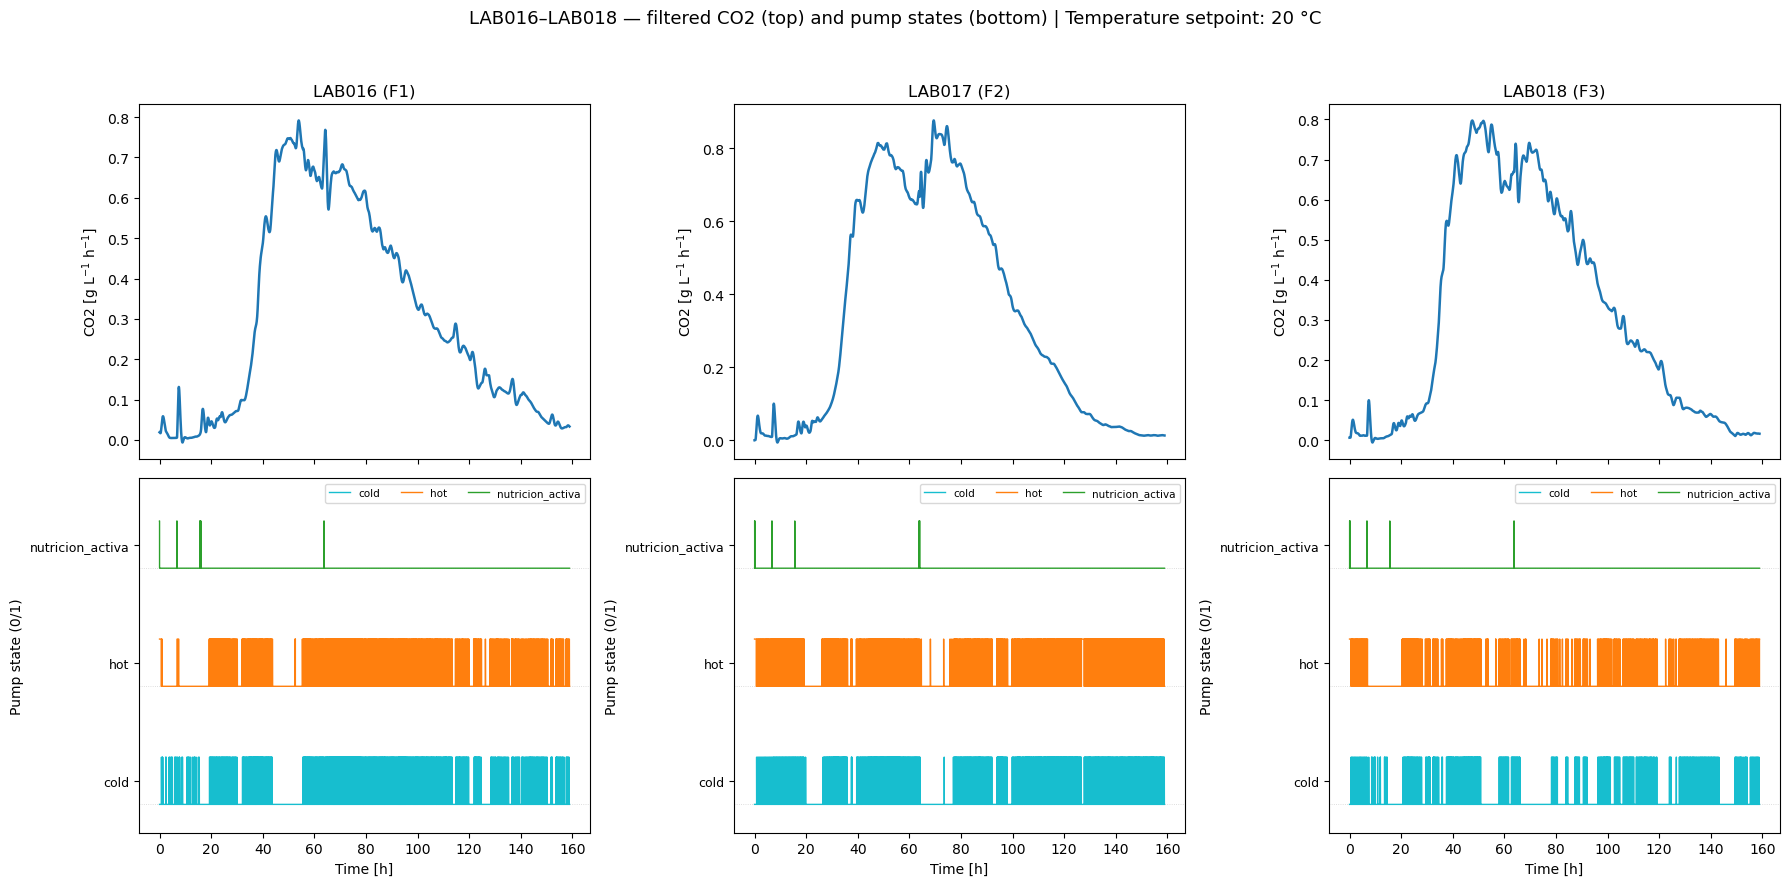


Pump activation summary (per fermenter, from the Temp_* CSVs):
  LAB016 -> cold: 702 events, 15.5 h ON | hot: 890 events, 13.0 h ON | nutricion_activa: 7 events, 0.3 h ON
  LAB017 -> cold: 750 events, 16.6 h ON | hot: 928 events, 20.0 h ON | nutricion_activa: 6 events, 0.4 h ON
  LAB018 -> cold: 487 events, 10.2 h ON | hot: 794 events, 9.7 h ON | nutricion_activa: 6 events, 0.3 h ON
freq_nut excluded: it is a pump frequency setting (1000/4000), not an ON/OFF activation state.


In [4]:
# ---- Official SCCM -> g L^-1 h^-1 conversion (visualization only, in memory) ----
# Replicated EXACTLY from lab090226_lab290226_co2_offline_filter_analysis.ipynb
# (which replicates flow_sccm_to_co2_g_l_h_plot from NEW_GUI_filtrado_vFINAL.py).
# The CSV files stay untouched (SCCM as recorded).
STANDARD_MOLAR_VOLUME_L_PER_MOL = 24.16
CO2_MOLAR_MASS_G_PER_MOL = 44.0095
REACTOR_WORKING_VOLUME_L = 2.0
CO2_FLOW_CORRECTION_FACTOR = 0.74
CO2_G_L_H_PER_SCCM = (CO2_MOLAR_MASS_G_PER_MOL * 60.0 * CO2_FLOW_CORRECTION_FACTOR
                      / (1000.0 * STANDARD_MOLAR_VOLUME_L_PER_MOL * REACTOR_WORKING_VOLUME_L))
print('Official conversion factor: 1 SCCM =', f'{CO2_G_L_H_PER_SCCM:.5f}', 'g L^-1 h^-1')

def sccm_to_g_l_h(flow_sccm):
    """Vectorized official SCCM -> g L^-1 h^-1 conversion (same formula as the repo)."""
    return flow_sccm * CO2_G_L_H_PER_SCCM

# ---- Main figure: 2 rows x 3 columns ----
# Top row: filtered CO2 converted to g L^-1 h^-1 (thicker line).
# Bottom row: pump activation states (0/1 digital pulses), one lane per channel.
labs = list(data.keys())
PULSE_COLS = ['cold', 'hot', 'nutricion_activa']
PULSE_COLORS = ['tab:cyan', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex='col')

for j, lab in enumerate(labs):
    d = data[lab]
    co2 = d['co2_filt']
    temp = d['temp']

    ax_co2 = axes[0, j]
    ax_co2.plot(co2['time_h'], sccm_to_g_l_h(co2[CO2_FILT_COL]), lw=1.8, color='tab:blue')
    ax_co2.set_title(lab + ' (' + d['fermenter'] + ')')
    ax_co2.set_ylabel('CO2 [g L$^{-1}$ h$^{-1}$]')

    ax_p = axes[1, j]
    for k, ch in enumerate(PULSE_COLS):
        base = 2.5 * k
        ax_p.axhline(base, color='lightgray', ls=':', lw=0.6, zorder=0)
        ax_p.step(temp['time_h'], base + temp[ch].astype(float), where='post',
                  lw=1.0, color=PULSE_COLORS[k], label=ch)
    ax_p.set_yticks([0.5, 3.0, 5.5])
    ax_p.set_yticklabels(PULSE_COLS, fontsize=9)
    ax_p.set_ylim(-0.6, 6.9)
    ax_p.set_ylabel('Pump state (0/1)')
    ax_p.set_xlabel('Time [h]')
    ax_p.legend(fontsize=7.5, ncol=3, loc='upper right', framealpha=0.75)

fig.suptitle('LAB016–LAB018 — filtered CO2 (top) and pump states (bottom) | Temperature setpoint: 20 °C',
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

print()
print('Pump activation summary (per fermenter, from the Temp_* CSVs):')
for lab, d in data.items():
    temp = d['temp']
    dt_med_s = float(temp['timestamp'].diff().dt.total_seconds().median())
    parts = []
    for ch in PULSE_COLS:
        s = temp[ch].astype(float)
        n_ev = int((s.diff() == 1).sum() + (1 if s.iloc[0] == 1 else 0))
        hours_on = float(s.sum()) * dt_med_s / 3600.0
        parts.append(ch + ': ' + str(n_ev) + ' events, ' + f'{hours_on:.1f}' + ' h ON')
    print(' ', lab, '->', ' | '.join(parts))
print('freq_nut excluded: it is a pump frequency setting (1000/4000), not an ON/OFF activation state.')

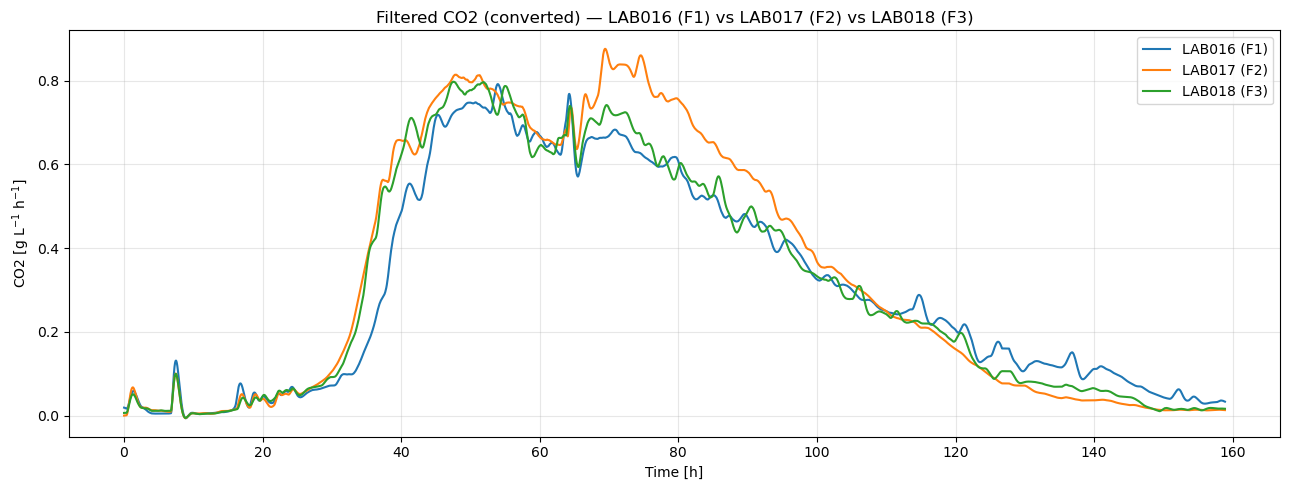

In [5]:
# Unique comparative figure of the three filtered CO2 signals (CO2_FILT), converted
# to g L^-1 h^-1 with the official repo factor. No normalization, no re-filtering.
fig, ax = plt.subplots(figsize=(13, 5))
for lab, d in data.items():
    co2 = d['co2_filt']
    ax.plot(co2['time_h'], sccm_to_g_l_h(co2[CO2_FILT_COL]), lw=1.5,
            label=lab + ' (' + d['fermenter'] + ')')
ax.set_xlabel('Time [h]')
ax.set_ylabel('CO2 [g L$^{-1}$ h$^{-1}$]')
ax.set_title('Filtered CO2 (converted) — LAB016 (F1) vs LAB017 (F2) vs LAB018 (F3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

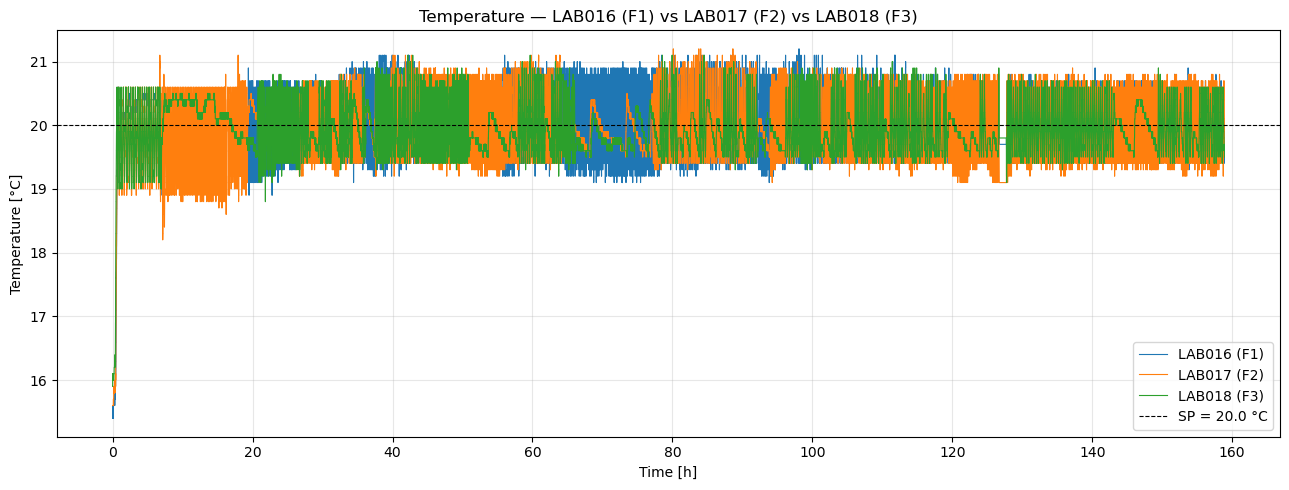

In [6]:
# Comparison of the three temperature profiles on a common time axis.
fig, ax = plt.subplots(figsize=(13, 5))
for lab, d in data.items():
    temp = d['temp']
    ax.plot(temp['time_h'], temp[TEMP_COL], lw=0.8, label=lab + ' (' + d['fermenter'] + ')')
ax.axhline(20.0, color='k', ls='--', lw=0.8, label='SP = 20.0 °C')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Temperature [°C]')
ax.set_title('Temperature — LAB016 (F1) vs LAB017 (F2) vs LAB018 (F3)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [7]:
# Numeric summary per LAB, from the signals as recorded:
# - CO2_filtered_max in SCCM (column flow_filt_sccm of the CO2_FILT files) and
#   converted to g L^-1 h^-1 with the official factor (in-memory, visualization only).
rows = []
for lab, d in data.items():
    co2 = d['co2_filt']
    temp = d['temp']
    imax = co2[CO2_FILT_COL].idxmax()
    max_sccm = float(co2[CO2_FILT_COL].max())
    rows.append({
        'LAB': lab,
        'Fermenter': d['fermenter'],
        'duration_h': round(float(co2['time_h'].iloc[-1]), 2),
        'CO2_filtered_max [SCCM]': round(max_sccm, 3),
        'CO2_filtered_max [g L^-1 h^-1]': round(max_sccm * CO2_G_L_H_PER_SCCM, 4),
        'time_CO2_max_h': round(float(co2['time_h'].loc[imax]), 2),
        'T_min_C': float(temp[TEMP_COL].min()),
        'T_mean_C': round(float(temp[TEMP_COL].mean()), 2),
        'T_max_C': float(temp[TEMP_COL].max()),
    })

summary = pd.DataFrame(rows)
summary

,LAB,Fermenter,duration_h,CO2_filtered_max [SCCM],CO2_filtered_max [g L^-1 h^-1],time_CO2_max_h,T_min_C,T_mean_C,T_max_C
0,LAB016,F1,158.88,19.580,0.7918,53.94,15.4,20.03,21.2
1,LAB017,F2,158.88,21.665,0.8761,69.43,15.6,19.93,21.2
2,LAB018,F3,158.88,19.723,0.7976,47.57,15.9,19.94,21.1


## Inoculation-aligned figures (t0 = END of the inoculation pulse, per fermenter)

**t0 refinement.** The midnight pulse of the inoculation pump (2026-09-01, `nutricion_activa` in the Temp CSVs) marks the inoculation. Per the campaign criterion, **t = 0 is the instant the pump returns to OFF (end of the pulse)**, not the start, and each fermenter keeps its own timestamp (they differ by a few seconds):

| LAB | Fermenter | inoculation_start | inoculation_end (= t0) | pulse duration |
| --- | --- | --- | --- | --- |
| LAB016 | F1 | 2026-09-01 00:00:03 | **2026-09-01 00:03:55** | 232 s |
| LAB017 | F2 | 2026-09-01 00:00:04 | **2026-09-01 00:04:00** | 236 s |
| LAB018 | F3 | 2026-09-01 00:00:01 | **2026-09-01 00:04:07** | 246 s |

Supporting evidence for the pulse as inoculation (inferred from the data; not explicitly documented in the repo): the pulse is simultaneous in the three reactors, it is the only midnight event of the run (other `nutricion_activa` events are start-up checks on Aug 31 while the must was tempering and operator doses on Sep 1/Sep 3), and gas CO2 onset occurs ≈9 h later (08:00–10:00 on Sep 1), a normal fermentation lag. Repository convention anchors `t = 0` to the real inoculation instant.

**Aligned copies (originals untouched, checksum-verified):** `LAB0xx_temperature_inoculation_aligned.csv` (from `Temp_Fx_LAB0xx.csv`) and `LAB0xx_co2_inoculation_aligned.csv` (from `CO2_FILT_Fx_LAB0xx.csv`) in `data/mem2026/LAB016-018/`. Each copy keeps every original row and column unchanged and adds `time_h = (timestamp − inoculation_end)/1 h` with the per-fermenter t0 above; pre-inoculation data is retained in the files with `time_h < 0`.

**Plotted range:** the aligned figures below show **only `time_h ≥ 0`** (post-inoculation), each with a vertical line at t = 0 ("Fin de inoculación"). Zoom figures cover the first 5 h post-inoculation (0 ≤ `time_h` ≤ 5 h) for CO2 and temperature. No filtering, interpolation or offset correction was applied to any signal.

LAB016 : inoculation start 2026-09-01 00:00:03 | end (t0) 2026-09-01 00:03:55 | duration 232 s
LAB017 : inoculation start 2026-09-01 00:00:04 | end (t0) 2026-09-01 00:04:00 | duration 236 s
LAB018 : inoculation start 2026-09-01 00:00:01 | end (t0) 2026-09-01 00:04:07 | duration 246 s
LAB016 : co2 plotted 45406 rows ( 2379 pre-inoculation rows excluded ) | temp plotted 88006 rows ( 7137 excluded ) | time_h [ 0.0 , 152.1 ] h


LAB017 : co2 plotted 45405 rows ( 2382 pre-inoculation rows excluded ) | temp plotted 88005 rows ( 7148 excluded ) | time_h [ 0.0 , 152.1 ] h
LAB018 : co2 plotted 45405 rows ( 2383 pre-inoculation rows excluded ) | temp plotted 88003 rows ( 7151 excluded ) | time_h [ 0.0 , 152.1 ] h


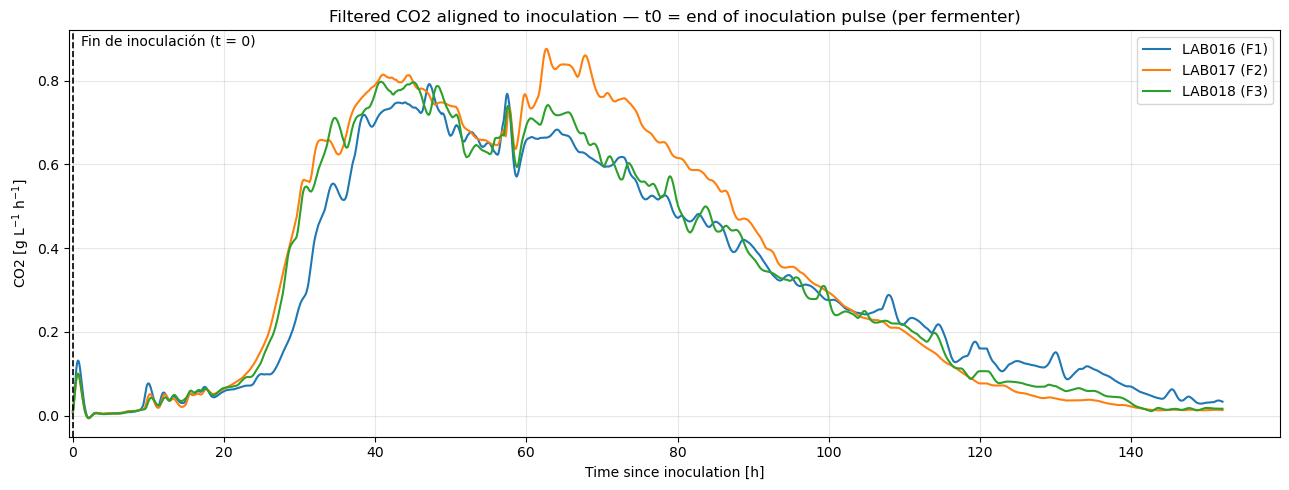

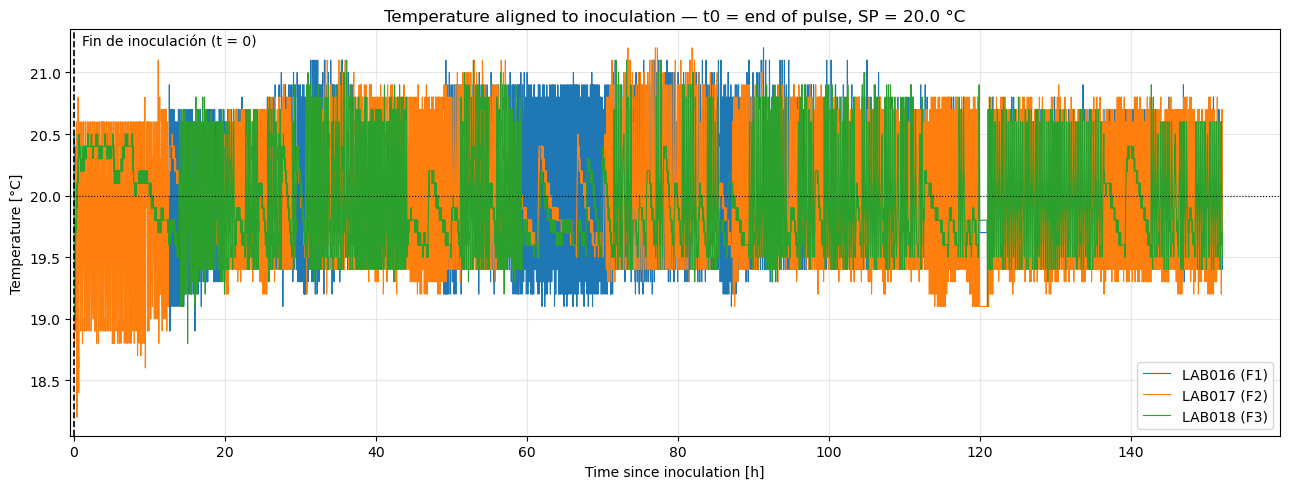

In [8]:
# ---- Inoculation-aligned figures (t0 = END of the inoculation pulse, per fermenter) ----
# Data source: the *_inoculation_aligned.csv COPIES in DATA_DIR (originals untouched).
# Plots show ONLY time_h >= 0 (post-inoculation); pre-inoculation rows stay in the files.
INOC_PULSE = {
    'LAB016': {'fermenter': 'F1', 'start': '2026-09-01 00:00:03', 'end': '2026-09-01 00:03:55',
               'temp': 'LAB016_temperature_inoculation_aligned.csv',
               'co2': 'LAB016_co2_inoculation_aligned.csv'},
    'LAB017': {'fermenter': 'F2', 'start': '2026-09-01 00:00:04', 'end': '2026-09-01 00:04:00',
               'temp': 'LAB017_temperature_inoculation_aligned.csv',
               'co2': 'LAB017_co2_inoculation_aligned.csv'},
    'LAB018': {'fermenter': 'F3', 'start': '2026-09-01 00:00:01', 'end': '2026-09-01 00:04:07',
               'temp': 'LAB018_temperature_inoculation_aligned.csv',
               'co2': 'LAB018_co2_inoculation_aligned.csv'},
}
# t0 = inoculation_end_timestamp (pump back to OFF), per fermenter
T0_INOC = {lab: pd.Timestamp(v['end']) for lab, v in INOC_PULSE.items()}
for lab, v in INOC_PULSE.items():
    dur = (pd.Timestamp(v['end']) - pd.Timestamp(v['start'])).total_seconds()
    print(lab, ': inoculation start', v['start'], '| end (t0)', v['end'],
          '| duration', f'{dur:.0f}', 's')

aligned = {}
for lab, spec in INOC_PULSE.items():
    a_co2 = pd.read_csv(DATA_DIR / spec['co2'], parse_dates=['timestamp'])
    a_temp = pd.read_csv(DATA_DIR / spec['temp'], parse_dates=['timestamp'])
    n_pre_co2 = int((a_co2['time_h'] < 0).sum())
    n_pre_temp = int((a_temp['time_h'] < 0).sum())
    a_co2 = a_co2[a_co2['time_h'] >= 0]
    a_temp = a_temp[a_temp['time_h'] >= 0]
    aligned[lab] = {'fermenter': spec['fermenter'], 'co2': a_co2, 'temp': a_temp}
    print(lab, ': co2 plotted', len(a_co2), 'rows (', n_pre_co2, 'pre-inoculation rows excluded )',
          '| temp plotted', len(a_temp), 'rows (', n_pre_temp, 'excluded )',
          '| time_h [', round(float(a_co2['time_h'].min()), 2), ',',
          round(float(a_co2['time_h'].max()), 2), '] h')


def mark_inoculation(ax, y_frac=0.96):
    ax.axvline(0, color='black', ls='--', lw=1.2)
    ax.annotate('Fin de inoculación (t = 0)', xy=(0, y_frac), xycoords=ax.get_xaxis_transform(),
                xytext=(6, 0), textcoords='offset points', fontsize=10, color='black')


# General aligned CO2 figure (time_h >= 0 only; official conversion to g L^-1 h^-1)
fig, ax = plt.subplots(figsize=(13, 5))
for lab, d in aligned.items():
    c = d['co2']
    ax.plot(c['time_h'], sccm_to_g_l_h(c[CO2_FILT_COL]), lw=1.5,
            label=lab + ' (' + d['fermenter'] + ')')
mark_inoculation(ax)
ax.set_xlim(left=-0.5)
ax.set_xlabel('Time since inoculation [h]')
ax.set_ylabel('CO2 [g L$^{-1}$ h$^{-1}$]')
ax.set_title('Filtered CO2 aligned to inoculation \u2014 t0 = end of inoculation pulse (per fermenter)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Aligned temperature figure (time_h >= 0 only)
fig, ax = plt.subplots(figsize=(13, 5))
for lab, d in aligned.items():
    t = d['temp']
    ax.plot(t['time_h'], t[TEMP_COL], lw=0.8, label=lab + ' (' + d['fermenter'] + ')')
mark_inoculation(ax)
ax.axhline(20.0, color='k', ls=':', lw=0.8)
ax.set_xlim(left=-0.5)
ax.set_xlabel('Time since inoculation [h]')
ax.set_ylabel('Temperature [°C]')
ax.set_title('Temperature aligned to inoculation \u2014 t0 = end of pulse, SP = 20.0 °C')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

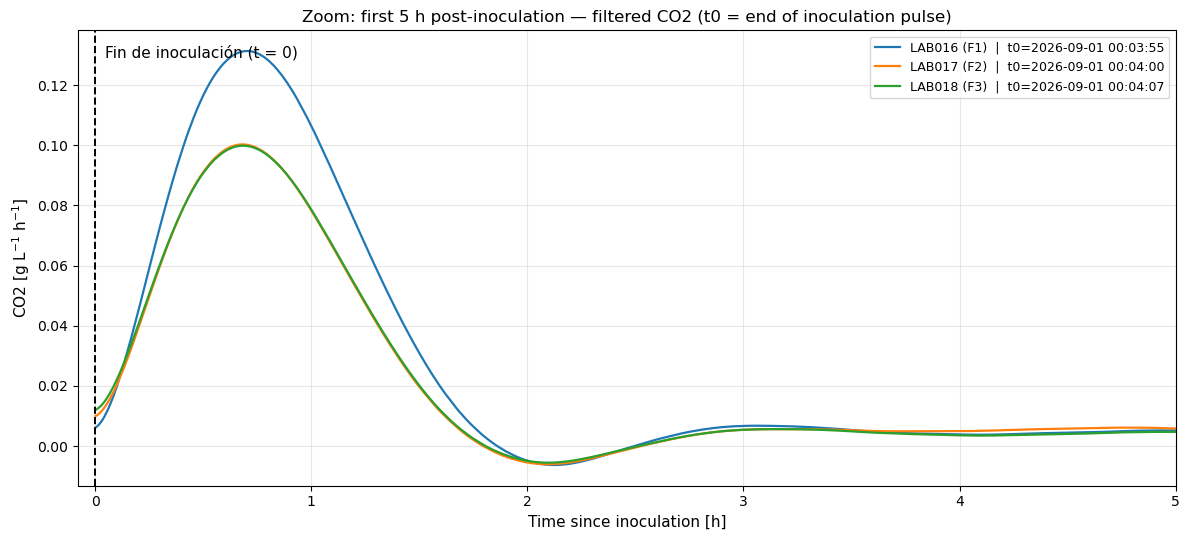

In [9]:
# ZOOM: filtered CO2 during the first 5 h post-inoculation (0 <= time_h <= 5).
# t0 = END of the inoculation pulse (pump OFF, per fermenter); time_h >= 0 only.
fig, ax = plt.subplots(figsize=(12, 5.5))
for lab, d in aligned.items():
    c = d['co2']
    z = c[c['time_h'] <= 5]
    ax.plot(z['time_h'], sccm_to_g_l_h(z[CO2_FILT_COL]), lw=1.6,
            label=lab + ' (' + d['fermenter'] + ')' + '  |  t0=' + str(T0_INOC[lab]))
ax.axvline(0, color='black', ls='--', lw=1.4)
ax.annotate('Fin de inoculación (t = 0)', xy=(0, 0.94), xycoords=ax.get_xaxis_transform(),
            xytext=(7, 0), textcoords='offset points', fontsize=11, color='black')
ax.set_xlim(-0.08, 5)
ax.set_xlabel('Time since inoculation [h]', fontsize=11)
ax.set_ylabel('CO2 [g L$^{-1}$ h$^{-1}$]', fontsize=11)
ax.set_title('Zoom: first 5 h post-inoculation \u2014 filtered CO2 (t0 = end of inoculation pulse)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

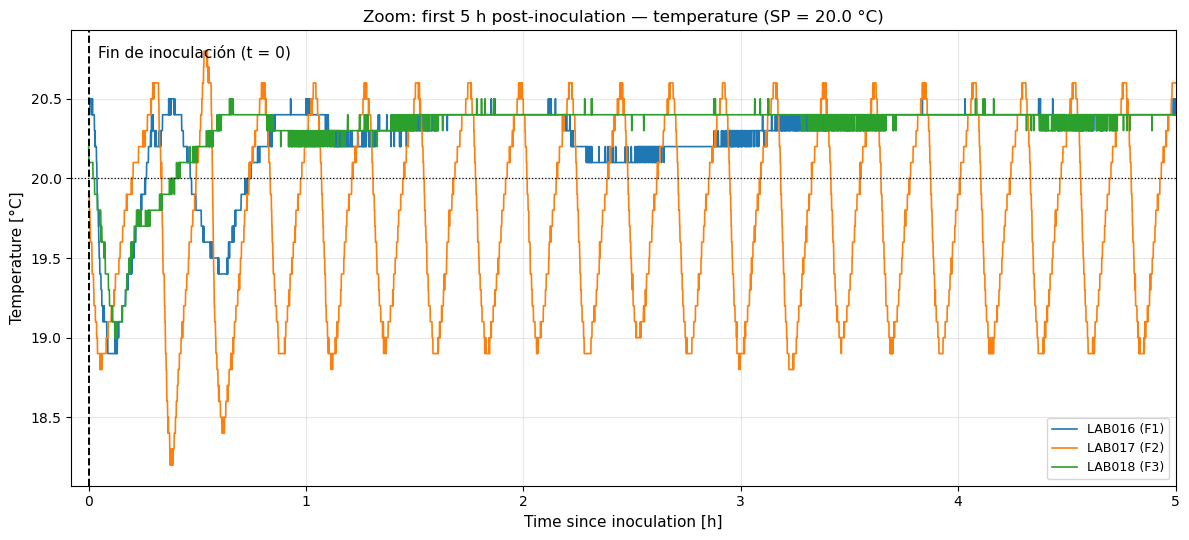

In [10]:
# ZOOM: temperature during the first 5 h post-inoculation (0 <= time_h <= 5).
fig, ax = plt.subplots(figsize=(12, 5.5))
for lab, d in aligned.items():
    t = d['temp']
    z = t[t['time_h'] <= 5]
    ax.plot(z['time_h'], z[TEMP_COL], lw=1.2, label=lab + ' (' + d['fermenter'] + ')')
ax.axvline(0, color='black', ls='--', lw=1.4)
ax.annotate('Fin de inoculación (t = 0)', xy=(0, 0.94), xycoords=ax.get_xaxis_transform(),
            xytext=(7, 0), textcoords='offset points', fontsize=11, color='black')
ax.axhline(20.0, color='k', ls=':', lw=0.9)
ax.set_xlim(-0.08, 5)
ax.set_xlabel('Time since inoculation [h]', fontsize=11)
ax.set_ylabel('Temperature [°C]', fontsize=11)
ax.set_title('Zoom: first 5 h post-inoculation \u2014 temperature (SP = 20.0 °C)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Initial observations LAB016–LAB018

**CO2 (CO2_FILT, official conversion to g L⁻¹ h⁻¹; SCCM in parentheses)**

- Same qualitative shape in the three fermenters: near-zero baseline to ~h 20–25, steep rise to ~h 45, broad maximum ~h 45–70, slow decay. F1's rise starts a few hours later than F2/F3's.
- **Amplitudes are similar**: max ≈0.79 (F1), ≈0.88 (F2), ≈0.80 g L⁻¹ h⁻¹ (≈19.6 / 21.7 / 19.7 SCCM) — F2 is ~10 % higher.
- **Time to maximum differs**: F3 ~h 48, F1 ~h 54, F2 ~h 69. All three show a sharp simultaneous dip around ~h 60–65; F2 rebounds highest to its global maximum.
- F2 and F3 approach zero by ~h 140–160; F1 keeps the highest residual level (~0.01–0.03 g L⁻¹ h⁻¹ ≈ 0.3–0.8 SCCM) with small fluctuations to the end of the record.

**Temperature and pump states**

- Temperature control is at **SP = 20.0 °C (band 0.5 °C)** in the three fermenters with very similar profiles (see the temperature comparison figure): cold start 15.4–15.9 °C, then on/off-style cycling between ~19.3 and 21.2 °C; means 19.9–20.0 °C.
- Pump channels (`cold`, `hot`, `nutricion_activa`): the thermal pumps alternate frequently, consistent with the on/off temperature control, while the nutrition pump works in short, sparse dosing pulses (6–7 activation events, ≈17–24 min total ON per fermenter in ≈159 h).
- The heating transient occurs while CO2 is still at baseline (start-up effect). No one-to-one correspondence between individual temperature/pump cycles and CO2 fluctuations is apparent at this time scale.

**Anomalies / data quality**

- One ~1 h logging gap hits all nine files at once (3614 s, ending 2026-09-06 ~01:00 ≈ h 127) → logger/PC interruption, not a per-sensor failure.
- Raw CO2 saturates at exactly 50.0000 SCCM in short spikes (`Alto rango`, 4–18 samples per fermenter); ≈2.1k–2.5k samples per fermenter are flagged `is_spike` in the CO2_FILT files. Small early bumps (~h 6–8, ≤ ~0.12 g L⁻¹ h⁻¹) and slightly negative converted values (≥ −0.006 g L⁻¹ h⁻¹) are filtering remnants/artifacts.
- F2 reports the most `Bajo rango` raw samples (890 vs 66/286). No NaNs, no duplicated timestamps; sampling ≈11 s (CO2) and ≈4 s (temperature).

*Descriptive notes only — no model fitting or causal interpretation is attempted in this notebook.*

## Pump-induced CO2 artifacts and fitting mask

The three temperature CSVs contain the verified binary states `cold`, `hot`, and `nutricion_activa`. `freq_nut` is a 1000/4000 frequency setting, not an ON/OFF signal. A pulse is one complete contiguous run at state 1; repeated ON rows are never counted as separate events. A pulse already ON in the first row is retained but marked as left-censored because its rising edge was not observed.

Artifact detection is deliberately separated from pulse detection. Every channel is screened against raw CO2, but only the sparse `nutricion_activa` events are eligible to trigger the fitting mask: the thermal channels cycle hundreds of times, have event-score medians below one Hampel threshold, and their occasional coincidences with raw excursions do not form a reproducible event-locked response. For each nutrition pulse, the raw-CO2 baseline is the preceding 1200 s (the unchanged IIR time constant). The event interval extends from the rising edge through the falling edge plus the unchanged 120 s Hampel memory. An artifact is detected only when the peak deviation exceeds the existing Hampel rule `max(3.5 * robust_sigma, 0.5 SCCM)`. Insufficient pre-event data is reported as ambiguous rather than classified.

Individual recovery cannot be separated robustly from biological evolution for every later or overlapping event. The common recovery is therefore estimated from the isolated, low-CO2 pulse near 6.72 h in all three fermenters. A centered 1200 s raw median supplies a diagnostic local trend (it does not replace or re-filter `flow_filt_sccm`). Recovery is the first full 1200 s interval in which at least 90% of `flow_filt_sccm - raw_trend` lies inside the same Hampel-compatible band measured before the pulse. The conservative common tail is the 95th percentile of the three observed post-pump recoveries, rounded upward to a whole minute. No optimizer is called and no file is written.

In [11]:
PUMP_STATE_COLS = ['cold', 'hot', 'nutricion_activa']
HAMPEL_WINDOW_S = 120.0
HAMPEL_K = 3.5
HAMPEL_MIN_ABS_SCCM = 0.5
IIR_TAU_S = 1200.0
IIR_ORDER = 3

def extract_binary_pulses(lab, fermenter, temp, channel):
    state = pd.to_numeric(temp[channel], errors='raise').astype(int)
    observed = set(state.unique())
    if not observed.issubset({0, 1}):
        raise ValueError(f'{lab} {channel} is not binary: {sorted(observed)}')

    rising = state.eq(1) & ~state.shift(fill_value=0).eq(1)
    falling = state.eq(0) & state.shift(fill_value=0).eq(1)
    start_indices = np.flatnonzero(rising.to_numpy())
    fall_indices = np.flatnonzero(falling.to_numpy())
    median_dt_s = float(temp['timestamp'].diff().dt.total_seconds().median())
    rows = []
    for pulse_number, start_i in enumerate(start_indices, start=1):
        fall_pos = np.searchsorted(fall_indices, start_i + 1)
        has_fall = fall_pos < len(fall_indices)
        start = temp['timestamp'].iloc[start_i]
        if has_fall:
            end = temp['timestamp'].iloc[fall_indices[fall_pos]]
        else:
            end = temp['timestamp'].iloc[-1] + pd.to_timedelta(median_dt_s, unit='s')
        rows.append({
            'LAB': lab,
            'fermenter': fermenter,
            'pump_channel': channel,
            'pulse_number': pulse_number,
            'signal_on': 1,
            'signal_off': 0,
            'rising_edge_observed': bool(start_i > 0),
            'falling_edge_observed': bool(has_fall),
            'pulse_start': start,
            'pulse_end': end,
            'pulse_start_h': (start - T0).total_seconds() / 3600.0,
            'pulse_end_h': (end - T0).total_seconds() / 3600.0,
            'pulse_duration_min': (end - start).total_seconds() / 60.0,
        })
    return pd.DataFrame(rows)

pulse_frames = []
for lab, d in data.items():
    temp = d['temp']
    missing = [c for c in PUMP_STATE_COLS if c not in temp.columns]
    if missing:
        raise KeyError(f'{lab}: missing pump columns {missing}')
    for channel in PUMP_STATE_COLS:
        pulse_frames.append(extract_binary_pulses(lab, d['fermenter'], temp, channel))

all_pulses = pd.concat(pulse_frames, ignore_index=True)
pulse_inventory_summary = (
    all_pulses.groupby(['LAB', 'fermenter', 'pump_channel'], as_index=False)
    .agg(n_pulses=('pulse_number', 'size'),
         median_duration_min=('pulse_duration_min', 'median'),
         max_duration_min=('pulse_duration_min', 'max'),
         n_left_censored=('rising_edge_observed', lambda s: int((~s).sum())),
         n_right_censored=('falling_edge_observed', lambda s: int((~s).sum())))
)

print('Verified binary pump channels and contiguous-run pulse counts:')
display(pulse_inventory_summary.round(3))
for lab, d in data.items():
    print(lab, 'freq_nut unique settings (not a state):', sorted(d['temp']['freq_nut'].dropna().unique()))

print('Nutrition-pump pulse ledger (all continuous ON runs):')
display(all_pulses.loc[all_pulses['pump_channel'].eq('nutricion_activa'), [
    'LAB', 'fermenter', 'pump_channel', 'pulse_number', 'signal_on', 'signal_off',
    'rising_edge_observed', 'falling_edge_observed', 'pulse_start', 'pulse_end',
    'pulse_start_h', 'pulse_end_h', 'pulse_duration_min'
]].round(4))

Verified binary pump channels and contiguous-run pulse counts:


,LAB,fermenter,pump_channel,n_pulses,median_duration_min,max_duration_min,n_left_censored,n_right_censored
0,LAB016,F1,cold,702,2.567,5.983,0,0
1,LAB016,F1,hot,890,1.075,38.850,1,0
2,LAB016,F1,nutricion_activa,7,1.767,3.867,1,0
3,LAB017,F2,cold,750,2.475,5.850,0,0
4,LAB017,F2,hot,928,1.967,63.183,1,0
5,LAB017,F2,nutricion_activa,6,3.108,7.833,0,0
6,LAB018,F3,cold,487,2.350,5.667,0,0
7,LAB018,F3,hot,794,0.308,31.667,1,1
8,LAB018,F3,nutricion_activa,6,3.183,4.133,0,0


LAB016 freq_nut unique settings (not a state): [1000.0, 4000.0]
LAB017 freq_nut unique settings (not a state): [1000.0, 4000.0]
LAB018 freq_nut unique settings (not a state): [1000.0, 4000.0]
Nutrition-pump pulse ledger (all continuous ON runs):


,LAB,fermenter,pump_channel,pulse_number,signal_on,signal_off,rising_edge_observed,falling_edge_observed,pulse_start,pulse_end,pulse_start_h,pulse_end_h,pulse_duration_min
1592,LAB016,F1,nutricion_activa,1,1,0,False,True,2026-08-31 17:17:27,2026-08-31 17:18:05,0.0100,0.0206,0.6333
1593,LAB016,F1,nutricion_activa,2,1,0,True,True,2026-08-31 17:20:05,2026-08-31 17:20:39,0.0539,0.0633,0.5667
1594,LAB016,F1,nutricion_activa,3,1,0,True,True,2026-09-01 00:00:03,2026-09-01 00:03:55,6.7200,6.7844,3.8667
1595,LAB016,F1,nutricion_activa,4,1,0,True,True,2026-09-01 08:52:38,2026-09-01 08:55:07,15.5964,15.6378,2.4833
1596,LAB016,F1,nutricion_activa,5,1,0,True,True,2026-09-01 09:05:26,2026-09-01 09:06:44,15.8097,15.8314,1.3000
1597,LAB016,F1,nutricion_activa,6,1,0,True,True,2026-09-01 09:19:43,2026-09-01 09:21:29,16.0478,16.0772,1.7667
1598,LAB016,F1,nutricion_activa,7,1,0,True,True,2026-09-03 09:00:03,2026-09-03 09:03:53,63.7200,63.7839,3.8333
3277,LAB017,F2,nutricion_activa,1,1,0,True,True,2026-08-31 17:20:02,2026-08-31 17:22:08,0.0531,0.0881,2.1000
3278,LAB017,F2,nutricion_activa,2,1,0,True,True,2026-08-31 17:24:39,2026-08-31 17:25:37,0.1300,0.1461,0.9667
3279,LAB017,F2,nutricion_activa,3,1,0,True,True,2026-09-01 00:00:04,2026-09-01 00:04:00,6.7203,6.7858,3.9333


In [12]:
# Screen every verified pump channel against raw CO2 using only the existing filter scales.
raw_arrays = {}
for lab, d in data.items():
    raw = d['co2_raw'].sort_values('timestamp')
    raw_arrays[lab] = (raw['timestamp'].astype('int64').to_numpy(),
                       raw[CO2_RAW_COL].to_numpy(dtype=float))

def score_pulse_against_raw(row):
    ts_ns, values = raw_arrays[row['LAB']]
    start_ns = pd.Timestamp(row['pulse_start']).value
    end_ns = pd.Timestamp(row['pulse_end']).value
    tau_ns = int(IIR_TAU_S * 1e9)
    memory_ns = int(HAMPEL_WINDOW_S * 1e9)
    p0, p1 = np.searchsorted(ts_ns, [start_ns - tau_ns, start_ns])
    e0 = np.searchsorted(ts_ns, start_ns)
    e1 = np.searchsorted(ts_ns, end_ns + memory_ns, side='right')
    pre = values[p0:p1]
    event = values[e0:e1]
    baseline_span_min = ((ts_ns[p1 - 1] - ts_ns[p0]) / 60e9
                         if len(pre) >= 2 else np.nan)
    if len(pre) < 3 or len(event) == 0:
        return pd.Series({
            'baseline_raw_sccm': np.nan, 'baseline_sigma_sccm': np.nan,
            'artifact_threshold_sccm': np.nan, 'immediate_change_sccm': np.nan,
            'peak_deviation_sccm': np.nan, 'event_score': np.nan,
            'artifact_candidate': pd.NA, 'artifact_onset': pd.NaT,
            'baseline_span_min': baseline_span_min,
        })
    baseline = float(np.median(pre))
    sigma = float(1.4826 * np.median(np.abs(pre - baseline)))
    threshold = max(HAMPEL_K * sigma, HAMPEL_MIN_ABS_SCCM)
    deviation = np.abs(event - baseline)
    peak_i = int(np.argmax(deviation))
    peak_deviation = float(deviation[peak_i])
    during_end = np.searchsorted(ts_ns[e0:e1], end_ns, side='left')
    during = event[:max(1, during_end)]
    detected = bool(peak_deviation > threshold)
    crossings = np.flatnonzero(deviation > threshold)
    onset = pd.to_datetime(ts_ns[e0 + crossings[0]]) if detected else pd.NaT
    return pd.Series({
        'baseline_raw_sccm': baseline,
        'baseline_sigma_sccm': sigma,
        'artifact_threshold_sccm': threshold,
        'immediate_change_sccm': float(np.median(during) - baseline),
        'peak_deviation_sccm': peak_deviation,
        'event_score': peak_deviation / threshold,
        'artifact_candidate': detected,
        'artifact_onset': onset,
        'baseline_span_min': baseline_span_min,
    })

pulse_scores = pd.concat(
    [all_pulses, all_pulses.apply(score_pulse_against_raw, axis=1)], axis=1
)
pulse_scores['artifact_candidate'] = pulse_scores['artifact_candidate'].astype('boolean')
channel_screening = (
    pulse_scores.groupby(['LAB', 'fermenter', 'pump_channel'], as_index=False)
    .agg(n_pulses=('pulse_number', 'size'),
         n_screenable=('artifact_candidate', 'count'),
         n_above_threshold=('artifact_candidate', lambda s: int(s.fillna(False).sum())),
         median_event_score=('event_score', 'median'))
)
channel_screening['percent_above_threshold'] = (
    100.0 * channel_screening['n_above_threshold'] / channel_screening['n_screenable']
)
channel_screening['used_as_mask_trigger'] = channel_screening['pump_channel'].eq('nutricion_activa')
print('Raw-CO2 event screening by channel:')
display(channel_screening.round(3))
print('Thermal-channel medians are below one event threshold; isolated crossings are coincidences, not a reproducible trigger.')

Raw-CO2 event screening by channel:


,LAB,fermenter,pump_channel,n_pulses,n_screenable,n_above_threshold,median_event_score,percent_above_threshold,used_as_mask_trigger
0,LAB016,F1,cold,702,702,47,0.373,6.695,False
1,LAB016,F1,hot,890,889,312,0.719,35.096,False
2,LAB016,F1,nutricion_activa,7,6,4,5.365,66.667,True
3,LAB017,F2,cold,750,750,106,0.453,14.133,False
4,LAB017,F2,hot,928,927,246,0.572,26.537,False
5,LAB017,F2,nutricion_activa,6,6,3,1.185,50.0,True
6,LAB018,F3,cold,487,487,50,0.392,10.267,False
7,LAB018,F3,hot,794,793,221,0.617,27.869,False
8,LAB018,F3,nutricion_activa,6,6,3,3.178,50.0,True


Thermal-channel medians are below one event threshold; isolated crossings are coincidences, not a reproducible trigger.


In [13]:
nutrition_scores = pulse_scores.loc[
    pulse_scores['pump_channel'].eq('nutricion_activa')
].copy()
nutrition_scores['baseline_abs_sccm'] = nutrition_scores['baseline_raw_sccm'].abs()
eligible_reference = (
    nutrition_scores['artifact_candidate'].fillna(False)
    & nutrition_scores['baseline_span_min'].ge(0.95 * IIR_TAU_S / 60.0)
)
reference_events = (
    nutrition_scores.loc[eligible_reference]
    .sort_values(['LAB', 'baseline_abs_sccm', 'pulse_start'])
    .groupby('LAB', group_keys=False).head(1)
)
if set(reference_events['LAB']) != set(data):
    raise RuntimeError('A full-baseline isolated reference pulse was not found for every LAB.')

def estimate_filtered_recovery(row):
    lab = row['LAB']
    raw = data[lab]['co2_raw'].sort_values('timestamp').copy()
    filt = data[lab]['co2_filt'].sort_values('timestamp').copy()
    raw_dt_s = float(raw['timestamp'].diff().dt.total_seconds().median())
    filt_dt_s = float(filt['timestamp'].diff().dt.total_seconds().median())
    min_periods = max(3, int(round((IIR_TAU_S / raw_dt_s) / 4.0)))
    raw_trend = (raw.set_index('timestamp')[CO2_RAW_COL]
                 .rolling(f'{int(IIR_TAU_S)}s', center=True, min_periods=min_periods)
                 .median())
    trend_frame = raw_trend.rename('raw_robust_trend_sccm').dropna().reset_index()
    aligned = pd.merge_asof(
        filt, trend_frame, on='timestamp', direction='nearest',
        tolerance=pd.to_timedelta(raw_dt_s, unit='s')
    ).dropna(subset=['raw_robust_trend_sccm'])
    aligned['filter_residual_sccm'] = (
        aligned[CO2_FILT_COL] - aligned['raw_robust_trend_sccm']
    )
    start, end = row['pulse_start'], row['pulse_end']
    tau = pd.to_timedelta(IIR_TAU_S, unit='s')
    pre = aligned.loc[
        aligned['timestamp'].between(start - tau, start, inclusive='left'),
        'filter_residual_sccm'
    ]
    center = float(pre.median())
    sigma = float(1.4826 * np.median(np.abs(pre - center)))
    tolerance = max(HAMPEL_K * sigma, HAMPEL_MIN_ABS_SCCM)
    post = aligned.loc[aligned['timestamp'].ge(end)].copy()
    post['compatible'] = post['filter_residual_sccm'].sub(center).abs().le(tolerance)
    sustain_n = max(1, int(round(IIR_TAU_S / filt_dt_s)))
    compatible_fraction = post['compatible'].rolling(sustain_n, min_periods=sustain_n).mean()
    endings = np.flatnonzero(compatible_fraction.to_numpy() >= 0.90)
    if len(endings) == 0:
        return pd.Series({'recovery_start': pd.NaT, 'recovery_after_pulse_end_min': np.nan,
                          'filtered_peak_delay_min': np.nan, 'recovery_tolerance_sccm': tolerance})
    recovery_i = max(0, int(endings[0]) - sustain_n + 1)
    recovery = post['timestamp'].iloc[recovery_i]
    peak_search = post.loc[post['timestamp'].lt(recovery + tau)]
    peak_i = peak_search['filter_residual_sccm'].sub(center).abs().idxmax()
    peak_time = peak_search.loc[peak_i, 'timestamp']
    return pd.Series({
        'recovery_start': recovery,
        'recovery_after_pulse_end_min': (recovery - end).total_seconds() / 60.0,
        'filtered_peak_delay_min': (peak_time - start).total_seconds() / 60.0,
        'recovery_tolerance_sccm': tolerance,
    })

recovery_diagnostics = pd.concat(
    [reference_events.reset_index(drop=True),
     reference_events.apply(estimate_filtered_recovery, axis=1).reset_index(drop=True)],
    axis=1,
)
if recovery_diagnostics['recovery_after_pulse_end_min'].isna().any():
    raise RuntimeError('At least one reference-pulse recovery could not be delimited.')
COMMON_RECOVERY_MIN = int(np.ceil(
    recovery_diagnostics['recovery_after_pulse_end_min'].quantile(0.95)
))
print('Empirical IIR recovery diagnostics from the isolated low-CO2 event:')
display(recovery_diagnostics[[
    'LAB', 'fermenter', 'pulse_start_h', 'pulse_duration_min',
    'filtered_peak_delay_min', 'recovery_after_pulse_end_min',
    'recovery_tolerance_sccm'
]].round(3))
print('Common conservative recovery tail (P95, rounded up) =', COMMON_RECOVERY_MIN, 'min after pump OFF')

artifact_table = nutrition_scores.copy()
artifact_table['artifact_detected'] = artifact_table['artifact_candidate'].astype('boolean')
artifact_table['artifact_start'] = artifact_table['artifact_onset']
artifact_table['artifact_end'] = pd.NaT
detected = artifact_table['artifact_detected'].fillna(False)
artifact_table.loc[detected, 'artifact_end'] = (
    artifact_table.loc[detected, 'pulse_end']
    + pd.to_timedelta(COMMON_RECOVERY_MIN, unit='min')
)
artifact_table['artifact_start_h'] = (artifact_table['artifact_start'] - T0).dt.total_seconds() / 3600.0
artifact_table['artifact_end_h'] = (artifact_table['artifact_end'] - T0).dt.total_seconds() / 3600.0
artifact_table['artifact_duration_min'] = (
    artifact_table['artifact_end'] - artifact_table['artifact_start']
).dt.total_seconds() / 60.0
artifact_table['peak_deviation_g_L_h'] = (
    artifact_table['peak_deviation_sccm'] * CO2_G_L_H_PER_SCCM
)

def artifact_note(row):
    if pd.isna(row['artifact_detected']):
        return 'Ambiguous: insufficient pre-pulse raw CO2; retained for manual review and not masked.'
    if bool(row['artifact_detected']):
        return f'Raw excursion > existing Hampel threshold; common {COMMON_RECOVERY_MIN}-min IIR tail applied.'
    return 'No excursion above the unchanged Hampel threshold; not masked.'

artifact_table['notes'] = artifact_table.apply(artifact_note, axis=1)
artifact_columns = [
    'LAB', 'fermenter', 'pump_channel', 'pulse_start_h', 'pulse_end_h',
    'pulse_duration_min', 'immediate_change_sccm', 'artifact_detected',
    'artifact_start_h', 'artifact_end_h', 'artifact_duration_min',
    'peak_deviation_sccm', 'peak_deviation_g_L_h', 'notes'
]
print('Per-pulse pressure-artifact audit (no invented bounds for unclear events):')
display(artifact_table[artifact_columns].round(4))

def merge_windows(frame):
    intervals = sorted(zip(frame['artifact_start'], frame['artifact_end']))
    merged = []
    for start, end in intervals:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return [(start, end) for start, end in merged]

exclusion_windows = {}
window_rows = []
for lab, d in data.items():
    co2 = d['co2_filt']
    co2['co2_filt_g_L_h'] = sccm_to_g_l_h(co2[CO2_FILT_COL])
    co2['co2_valid_for_fitting'] = True
    lab_detected = artifact_table.loc[
        artifact_table['LAB'].eq(lab) & artifact_table['artifact_detected'].fillna(False)
    ]
    exclusion_windows[lab] = merge_windows(lab_detected)
    for window_number, (start, end) in enumerate(exclusion_windows[lab], start=1):
        inside = co2['timestamp'].between(start, end, inclusive='both')
        co2.loc[inside, 'co2_valid_for_fitting'] = False
        window_rows.append({
            'LAB': lab, 'fermenter': d['fermenter'], 'window_number': window_number,
            'window_start': start, 'window_end': end,
            'window_start_h': (start - T0).total_seconds() / 3600.0,
            'window_end_h': (end - T0).total_seconds() / 3600.0,
            'window_duration_min': (end - start).total_seconds() / 60.0,
        })
exclusion_windows_df = pd.DataFrame(window_rows)
print('Merged exclusion windows used by co2_valid_for_fitting:')
display(exclusion_windows_df.round(4))

Empirical IIR recovery diagnostics from the isolated low-CO2 event:


,LAB,fermenter,pulse_start_h,pulse_duration_min,filtered_peak_delay_min,recovery_after_pulse_end_min,recovery_tolerance_sccm
0,LAB016,F1,6.720,3.867,47.133,89.383,0.5
1,LAB017,F2,6.720,3.933,44.717,86.050,0.5
2,LAB018,F3,6.719,4.100,45.117,81.667,0.5


Common conservative recovery tail (P95, rounded up) = 90 min after pump OFF
Per-pulse pressure-artifact audit (no invented bounds for unclear events):


,LAB,fermenter,pump_channel,pulse_start_h,pulse_end_h,pulse_duration_min,immediate_change_sccm,artifact_detected,artifact_start_h,artifact_end_h,artifact_duration_min,peak_deviation_sccm,peak_deviation_g_L_h,notes
1592,LAB016,F1,nutricion_activa,0.0100,0.0206,0.6333,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,Ambiguous: insufficient pre-pulse raw CO2; ret...
1593,LAB016,F1,nutricion_activa,0.0539,0.0633,0.5667,-0.0132,False,NaN,NaN,NaN,0.0950,0.0038,No excursion above the unchanged Hampel thresh...
1594,LAB016,F1,nutricion_activa,6.7200,6.7844,3.8667,41.9658,True,6.7222,8.2844,93.7333,45.8668,1.8548,Raw excursion > existing Hampel threshold; com...
1595,LAB016,F1,nutricion_activa,15.5964,15.6378,2.4833,0.1557,False,NaN,NaN,NaN,0.4197,0.0170,No excursion above the unchanged Hampel thresh...
1596,LAB016,F1,nutricion_activa,15.8097,15.8314,1.3000,-0.6968,True,15.8111,17.3314,91.2167,5.2233,0.2112,Raw excursion > existing Hampel threshold; com...
1597,LAB016,F1,nutricion_activa,16.0478,16.0772,1.7667,25.2534,True,16.0503,17.5772,91.6167,25.5437,1.0330,Raw excursion > existing Hampel threshold; com...
1598,LAB016,F1,nutricion_activa,63.7200,63.7839,3.8333,27.3464,True,63.7206,65.2839,93.8000,31.5482,1.2758,Raw excursion > existing Hampel threshold; com...
3277,LAB017,F2,nutricion_activa,0.0531,0.0881,2.1000,-0.0065,False,NaN,NaN,NaN,0.1171,0.0047,No excursion above the unchanged Hampel thresh...
3278,LAB017,F2,nutricion_activa,0.1300,0.1461,0.9667,-0.0039,False,NaN,NaN,NaN,0.1394,0.0056,No excursion above the unchanged Hampel thresh...
3279,LAB017,F2,nutricion_activa,6.7203,6.7858,3.9333,29.8480,True,6.7222,8.2858,93.8167,37.2659,1.5070,Raw excursion > existing Hampel threshold; com...


Merged exclusion windows used by co2_valid_for_fitting:


,LAB,fermenter,window_number,window_start,window_end,window_start_h,window_end_h,window_duration_min
0,LAB016,F1,1,2026-09-01 00:00:11,2026-09-01 01:33:55,6.7222,8.2844,93.7333
1,LAB016,F1,2,2026-09-01 09:05:31,2026-09-01 10:51:29,15.8111,17.5772,105.9667
2,LAB016,F1,3,2026-09-03 09:00:05,2026-09-03 10:33:53,63.7206,65.2839,93.8000
3,LAB017,F2,1,2026-09-01 00:00:11,2026-09-01 01:34:00,6.7222,8.2858,93.8167
4,LAB017,F2,2,2026-09-03 09:00:05,2026-09-03 10:49:52,63.7206,65.5503,109.7833
5,LAB018,F3,1,2026-08-31 17:30:28,2026-08-31 18:59:27,0.2269,1.7100,88.9833
6,LAB018,F3,2,2026-09-01 00:00:01,2026-09-01 01:34:07,6.7194,8.2878,94.1000
7,LAB018,F3,3,2026-09-03 09:00:05,2026-09-03 10:34:09,63.7206,65.2883,94.0667


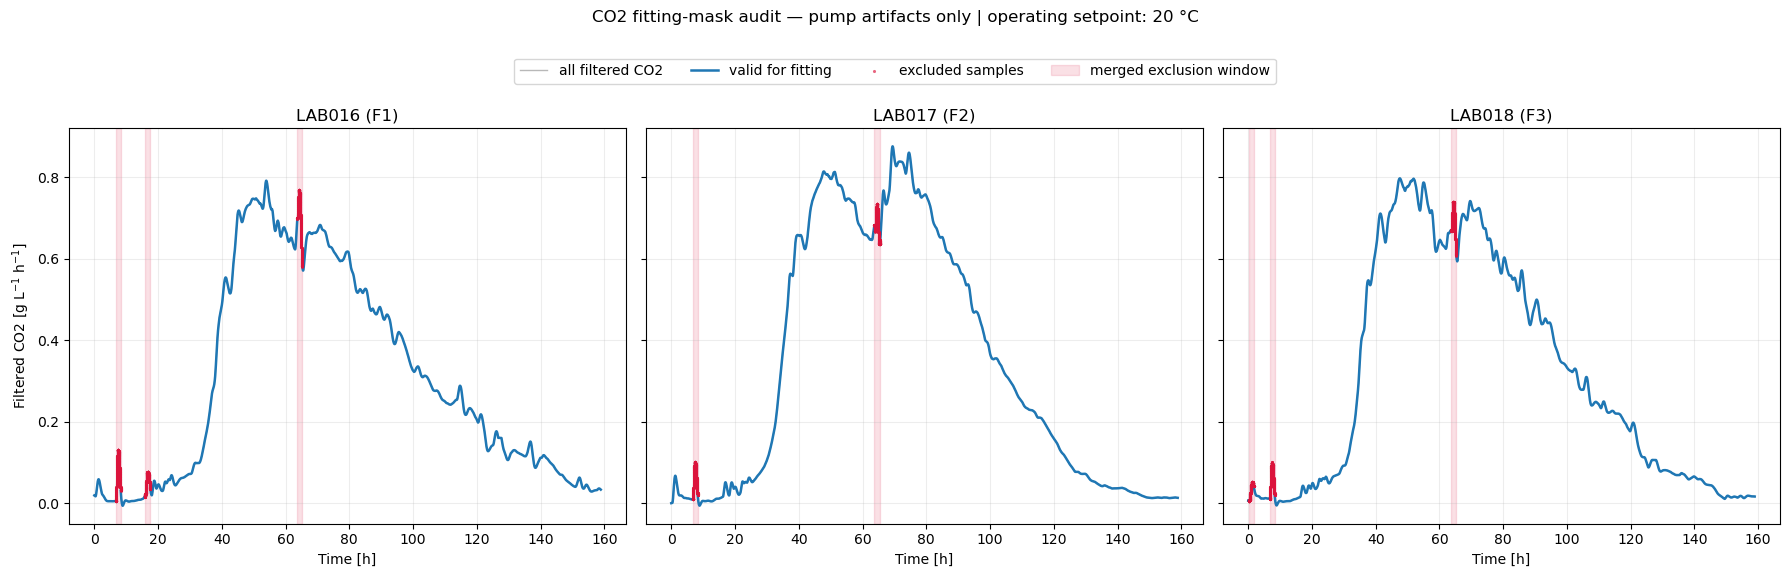

In [14]:
# One compact audit figure: the original filtered trace, retained support, and excluded windows.
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), sharey=True)
for ax, (lab, d) in zip(axes, data.items()):
    co2 = d['co2_filt']
    valid = co2['co2_valid_for_fitting']
    y = co2['co2_filt_g_L_h']
    ax.plot(co2['time_h'], y, color='0.72', lw=1.0, label='all filtered CO2')
    ax.plot(co2['time_h'], y.where(valid), color='tab:blue', lw=1.8,
            label='valid for fitting')
    ax.scatter(co2.loc[~valid, 'time_h'], y.loc[~valid], s=5, color='crimson',
               alpha=0.65, linewidths=0, label='excluded samples', zorder=3)
    for window_i, (start, end) in enumerate(exclusion_windows[lab]):
        ax.axvspan((start - T0).total_seconds() / 3600.0,
                   (end - T0).total_seconds() / 3600.0,
                   color='crimson', alpha=0.13,
                   label='merged exclusion window' if window_i == 0 else None)
    ax.set_title(f'{lab} ({d["fermenter"]})')
    ax.set_xlabel('Time [h]')
    ax.grid(alpha=0.22)
axes[0].set_ylabel('Filtered CO2 [g L$^{-1}$ h$^{-1}$]')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('CO2 fitting-mask audit — pump artifacts only | operating setpoint: 20 °C', y=1.10)
fig.tight_layout()
plt.show()

In [15]:
def trapezoid_auc_without_gaps(frame, valid=None):
    time_h = frame['timestamp'].astype('int64').to_numpy(dtype=float) / 3.6e12
    values = frame['co2_filt_g_L_h'].to_numpy(dtype=float)
    dt_h = np.diff(time_h)
    positive_dt = dt_h[dt_h > 0]
    median_dt_h = float(np.median(positive_dt))
    pair_ok = (dt_h > 0) & (dt_h <= 1.5 * median_dt_h)
    pair_ok &= np.isfinite(values[:-1]) & np.isfinite(values[1:])
    if valid is not None:
        valid_array = np.asarray(valid, dtype=bool)
        pair_ok &= valid_array[:-1] & valid_array[1:]
    return float(np.sum(0.5 * (values[:-1] + values[1:]) * dt_h * pair_ok))

impact_rows = []
for lab, d in data.items():
    co2 = d['co2_filt']
    valid = co2['co2_valid_for_fitting']
    n_total = len(co2)
    n_excluded = int((~valid).sum())
    coverage_start, coverage_end = co2['timestamp'].iloc[[0, -1]]
    excluded_h = 0.0
    for start, end in exclusion_windows[lab]:
        clipped_start, clipped_end = max(start, coverage_start), min(end, coverage_end)
        excluded_h += max(0.0, (clipped_end - clipped_start).total_seconds() / 3600.0)
    lab_artifacts = artifact_table.loc[
        artifact_table['LAB'].eq(lab) & artifact_table['artifact_detected'].fillna(False)
    ]
    impact_rows.append({
        'LAB': lab,
        'fermenter': d['fermenter'],
        'n_total_samples': n_total,
        'n_excluded_samples': n_excluded,
        'percent_excluded': 100.0 * n_excluded / n_total,
        'n_nutrition_pulses': int(artifact_table['LAB'].eq(lab).sum()),
        'n_artifact_pulses': len(lab_artifacts),
        'total_excluded_h': excluded_h,
        'median_artifact_duration_min': lab_artifacts['artifact_duration_min'].median(),
        'max_artifact_duration_min': lab_artifacts['artifact_duration_min'].max(),
        'CO2_peak_original_g_L_h': co2['co2_filt_g_L_h'].max(),
        'CO2_peak_valid_g_L_h': co2.loc[valid, 'co2_filt_g_L_h'].max(),
        'AUC_total_no_logging_gaps_g_L': trapezoid_auc_without_gaps(co2),
        'AUC_valid_no_mask_bridging_g_L': trapezoid_auc_without_gaps(co2, valid),
    })
impact_summary = pd.DataFrame(impact_rows)
display(impact_summary.round(4))
print('AUC_valid integrates only adjacent valid pairs: excluded windows and the logger gap are not bridged or interpolated.')
print('Therefore AUC_valid is a support audit, not a directly comparable cumulative-production estimate.')

,LAB,fermenter,n_total_samples,n_excluded_samples,percent_excluded,n_nutrition_pulses,n_artifact_pulses,total_excluded_h,median_artifact_duration_min,max_artifact_duration_min,CO2_peak_original_g_L_h,CO2_peak_valid_g_L_h,AUC_total_no_logging_gaps_g_L,AUC_valid_no_mask_bridging_g_L
0,LAB016,F1,47785,1705,3.5681,7,4,4.8917,92.6750,93.8000,0.7918,0.7918,44.9682,43.6508
1,LAB017,F2,47787,1178,2.4651,6,3,3.3933,93.8833,97.7667,0.8761,0.8761,49.6448,48.2955
2,LAB018,F3,47788,1608,3.3649,6,3,4.6192,94.0667,94.1000,0.7976,0.7976,45.7176,44.4827


AUC_valid integrates only adjacent valid pairs: excluded windows and the logger gap are not bridged or interpolated.
Therefore AUC_valid is a support audit, not a directly comparable cumulative-production estimate.


In [16]:
detected_counts = (artifact_table.loc[artifact_table['artifact_detected'].fillna(False)]
                   .groupby('LAB').size().reindex(data, fill_value=0).to_dict())
pct_text = ', '.join(
    f"{row.LAB}: {row.percent_excluded:.2f}%" for row in impact_summary.itertuples()
)
recovery_min = recovery_diagnostics['recovery_after_pulse_end_min'].min()
recovery_max = recovery_diagnostics['recovery_after_pulse_end_min'].max()
peak_delay = recovery_diagnostics['filtered_peak_delay_min'].median()
typical_duration = artifact_table.loc[
    artifact_table['artifact_detected'].fillna(False), 'artifact_duration_min'
].median()
ambiguous = artifact_table.loc[artifact_table['artifact_detected'].isna()]
ambiguous_text = (
    ', '.join(f"{r.LAB} pulse {r.pulse_number} ({r.pulse_start_h:.3f} h)"
              for r in ambiguous.itertuples())
    if len(ambiguous) else 'none'
)

display(Markdown(f'''
### Interpretation

1. **¿Los pulsos generan artefactos reproducibles?** Sí, pero no todos los pulsos ni todos los canales. Los eventos de `nutricion_activa` detectados ({detected_counts}) muestran excursiones crudas abruptas positivas o negativas; el evento sincronizado de ~6.72 h se repite en F1–F3. `cold` y `hot` tienen cientos de ciclos, una mediana de score inferior a un umbral Hampel y no ofrecen una respuesta evento-bloqueada atribuible, por lo que no disparan la máscara.
2. **¿Cuánto duran?** El pulso mecánico dura minutos, pero la ventana contaminada típica es ~{typical_duration:.1f} min al sumar la cola común. En los tres eventos de referencia la recuperación observada ocurrió {recovery_min:.1f}–{recovery_max:.1f} min después de apagar la bomba; el P95 redondeado da {COMMON_RECOVERY_MIN} min.
3. **¿Termina al apagarse la bomba?** No. La discrepancia entre CO2 filtrado y tendencia cruda robusta persiste mucho después del falling edge.
4. **¿El IIR extiende el efecto?** Sí. La máxima desviación filtrada aparece típicamente ~{peak_delay:.1f} min después del rising edge, muy posterior al pulso de pocos minutos, y la compatibilidad no retorna hasta ~1.5 h después de OFF. Esto es coherente con el Butterworth causal de orden {IIR_ORDER} y tau={IIR_TAU_S/60:.0f} min ya aplicado; no se volvió a filtrar la señal.
5. **¿Es razonable excluir estas ventanas de la calibración offline?** Sí: son intervalos donde `flow_filt_sccm` conserva memoria de una perturbación mecánica demostrada en la señal cruda. La exclusión es condicional al umbral existente, no a toda activación de bomba.
6. **¿Qué porcentaje se pierde?** {pct_text}.
7. **¿Se preserva la dinámica biológica posterior?** En apariencia sí: los pulsos sin excursión cruda se conservan y la máscara termina al recuperar compatibilidad con la tendencia robusta. Aun así, en eventos tardíos la evolución biológica y la cola instrumental se superponen, razón por la cual se usa una cola común estimada en el evento aislado en vez de atribuir todo cambio posterior a la nutrición.
8. **¿Recomendación?** Sí, usar `co2_valid_for_fitting` en la siguiente calibración offline, manteniendo `flow_filt_sccm` y `co2_filt_g_L_h` sin alteraciones. Recomiendo revisar manualmente el caso ambiguo ({ambiguous_text}) y los clusters solapados F1 ~15.81–16.05 h y F2 ~63.72–63.92 h antes de congelar la política.

**Cautela causal:** la coincidencia temporal entre nutrición y un cambio posterior de CO2 no demuestra que la nutrición lo haya causado. La máscara sólo codifica evidencia instrumental inmediata y la memoria observada del filtro.
'''))


### Interpretation

1. **¿Los pulsos generan artefactos reproducibles?** Sí, pero no todos los pulsos ni todos los canales. Los eventos de `nutricion_activa` detectados ({'LAB016': 4, 'LAB017': 3, 'LAB018': 3}) muestran excursiones crudas abruptas positivas o negativas; el evento sincronizado de ~6.72 h se repite en F1–F3. `cold` y `hot` tienen cientos de ciclos, una mediana de score inferior a un umbral Hampel y no ofrecen una respuesta evento-bloqueada atribuible, por lo que no disparan la máscara.
2. **¿Cuánto duran?** El pulso mecánico dura minutos, pero la ventana contaminada típica es ~93.8 min al sumar la cola común. En los tres eventos de referencia la recuperación observada ocurrió 81.7–89.4 min después de apagar la bomba; el P95 redondeado da 90 min.
3. **¿Termina al apagarse la bomba?** No. La discrepancia entre CO2 filtrado y tendencia cruda robusta persiste mucho después del falling edge.
4. **¿El IIR extiende el efecto?** Sí. La máxima desviación filtrada aparece típicamente ~45.1 min después del rising edge, muy posterior al pulso de pocos minutos, y la compatibilidad no retorna hasta ~1.5 h después de OFF. Esto es coherente con el Butterworth causal de orden 3 y tau=20 min ya aplicado; no se volvió a filtrar la señal.
5. **¿Es razonable excluir estas ventanas de la calibración offline?** Sí: son intervalos donde `flow_filt_sccm` conserva memoria de una perturbación mecánica demostrada en la señal cruda. La exclusión es condicional al umbral existente, no a toda activación de bomba.
6. **¿Qué porcentaje se pierde?** LAB016: 3.57%, LAB017: 2.47%, LAB018: 3.36%.
7. **¿Se preserva la dinámica biológica posterior?** En apariencia sí: los pulsos sin excursión cruda se conservan y la máscara termina al recuperar compatibilidad con la tendencia robusta. Aun así, en eventos tardíos la evolución biológica y la cola instrumental se superponen, razón por la cual se usa una cola común estimada en el evento aislado en vez de atribuir todo cambio posterior a la nutrición.
8. **¿Recomendación?** Sí, usar `co2_valid_for_fitting` en la siguiente calibración offline, manteniendo `flow_filt_sccm` y `co2_filt_g_L_h` sin alteraciones. Recomiendo revisar manualmente el caso ambiguo (LAB016 pulse 1 (0.010 h)) y los clusters solapados F1 ~15.81–16.05 h y F2 ~63.72–63.92 h antes de congelar la política.

**Cautela causal:** la coincidencia temporal entre nutrición y un cambio posterior de CO2 no demuestra que la nutrición lo haya causado. La máscara sólo codifica evidencia instrumental inmediata y la memoria observada del filtro.
